# 2.4 Bluesky Ã¢â‚¬â€ NLP Ã¢â‚¬â€ LDA Topic Modeling

This notebook applies Latent Dirichlet Allocation (LDA) to Bluesky silver-layer data to uncover latent discussion topics across candidate buzz clusters (TrumpBuzz Ã‚Â· HarrisBuzz Ã‚Â· ElectionBuzz).

**Pipeline:**  
Silver Ã¢â€ â€™ LDA preprocessing Ã¢â€ â€™ dictionary/corpus Ã¢â€ â€™ coherence tuning Ã¢â€ â€™ final LDA model Ã¢â€ â€™ topic-per-buzz analysis

**Input:** `Data/2_Silver/Bluesky/bluesky_clean.csv`


<!-- toc -->
## Contents
- [Setup](#setup)
- [1. Preprocessing](#1-preprocessing)
- [2. LDA Ã¢â‚¬â€ Build Dictionary & Corpus](#2-lda-build-dictionary-corpus)
- [3. LDA Ã¢â‚¬â€ Coherence Score](#3-lda-coherence-score)
- [4. LDA Ã¢â‚¬â€ Train Final Model](#4-lda-train-final-model)
- [5. Topic per Buzz Group](#5-topic-per-buzz-group)


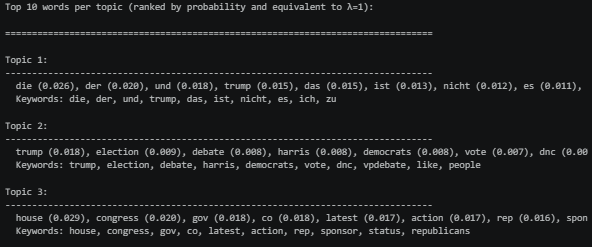

This was the output of LDA topic modeling when non-English rows were not filtered. German was a prominent topic, therefore we use the properly filtered (only english) dataset from Bluesky Silver map (made in **2.2_textual_analysis.ipynb** notebook)

## Setup

In [18]:
import os
import sys
import time
import re
import string
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# Navigate to project root so Data/ paths resolve correctly
cwd = Path.cwd().resolve()
search_bases = [cwd, *cwd.parents]
search_suffixes = [
    Path('.'),
    Path('group-project-SMWA'),
    Path('Social media and webanalytics') / 'group-project-SMWA',
]
PROJECT_ROOT = None
for base in search_bases:
    for suffix in search_suffixes:
        p = (base / suffix).resolve()
        if (p / 'house_style.py').exists() and (p / 'Data').exists():
            PROJECT_ROOT = p
            break
    if PROJECT_ROOT is not None:
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not locate project root containing house_style.py and Data/')
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

# House style
from house_style import *
apply_style()

# Output dirs
FIGURES_DIR = Path(PROJECT_ROOT) / "latex_template" / "figures" / "bluesky"
TABLES_DIR  = FIGURES_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# LDA
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from sklearn.feature_extraction.text import CountVectorizer

# NLTK
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
from wordcloud import WordCloud


def render_table_png(df, out_path, title=None, dpi=150):
    """Save a DataFrame as a styled PNG table (financials macro style)."""
    import matplotlib as mpl
    n_rows, n_cols = df.shape
    col_strs = [str(c) for c in df.columns]
    char_widths = []
    for j, col in enumerate(df.columns):
        max_data = df[col].astype(str).str.len().max() if len(df) > 0 else 0
        char_widths.append(max(len(str(col)), int(max_data)) + 2)
    total_chars = sum(char_widths)
    col_widths  = [w / total_chars for w in char_widths]

    fig_w = max(8, min(16, total_chars * 0.12))
    fig_h = max(2, 0.5 + n_rows * 0.42)
    fig = plt.figure(figsize=(fig_w, fig_h))
    fig.patch.set_facecolor(BG_DARK)

    ax = fig.add_axes([0.01, 0.04, 0.98, 0.88])
    ax.set_facecolor(BG_DARK)
    ax.axis("off")

    cell_text  = df.astype(str).values.tolist()
    col_labels = list(df.columns)

    tbl = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        colWidths=col_widths,
        loc="center",
        cellLoc="left",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.0, 2.0)

    header_color = "#1c2d3e"
    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor(SPINE_COLOR)
        cell.set_linewidth(0.6)
        if row == 0:
            cell.set_facecolor(header_color)
            cell.get_text().set_color(TEXT_PRIMARY)
            cell.get_text().set_fontweight("bold")
            cell.get_text().set_fontsize(12)
        else:
            cell.set_facecolor(BG_PANEL if row % 2 == 0 else BG_DARK)
            cell.get_text().set_color(TEXT_PRIMARY)

    if title:
        fig.text(0.5, 0.97, title, ha="center", va="top",
                 color=TEXT_PRIMARY, fontsize=12, fontweight="bold")

    fig.savefig(out_path, dpi=dpi, bbox_inches="tight",
                facecolor=BG_DARK, edgecolor="none")
    plt.close(fig)


print(f"Working directory: {os.getcwd()}")
print("Libraries imported successfully!")
print(f"Figures dir: {FIGURES_DIR}")
print(f"Tables dir:  {TABLES_DIR}")

Working directory: C:\Users\verme_hzys4y0\UGent\2025-2026\Social media and webanalytics\group-project-SMWA
Libraries imported successfully!
Figures dir: C:\Users\verme_hzys4y0\UGent\2025-2026\Social media and webanalytics\group-project-SMWA\latex_template\figures\bluesky
Tables dir:  C:\Users\verme_hzys4y0\UGent\2025-2026\Social media and webanalytics\group-project-SMWA\latex_template\figures\bluesky\tables


In [19]:
data_path = Path(PROJECT_ROOT) / 'Data' / '2_Silver' / 'Bluesky' / 'bluesky_clean.csv'
df_clean = pd.read_csv(data_path, parse_dates=['timestamp'])
df_clean['timestamp']      = pd.to_datetime(df_clean['timestamp'], format='ISO8601', utc=True).dt.normalize()
df_clean['text_clean'] = df_clean['text_clean'].fillna('')
df_clean['text']      = df_clean['text'].fillna('')

print(f'Ã¢Å“â€œ Loaded {len(df_clean):,} rows  |  {df_clean["timestamp"].min().timestamp()} Ã¢â€ â€™ {df_clean["timestamp"].max().timestamp()}')
print(df_clean['candidate'].value_counts())

Ã¢Å“â€œ Loaded 26,964 rows  |  1720137600.0 Ã¢â€ â€™ 1768780800.0
candidate
TrumpBuzz       11056
ElectionBuzz     8156
HarrisBuzz       7752
Name: count, dtype: int64


## 1. Preprocessing

- **LDA**: `text_norm` is already cleaned Ã¢â‚¬â€ we just tokenise and filter short tokens

In [20]:
# LDA preprocessing 

def preprocess_for_lda(text):
    if not isinstance(text, str) or not text.strip():
        return []
    tokens = word_tokenize(text.lower())
    # Add domain-specific stops on top of already-cleaned text
    extra_stops = {}
    tokens = [w for w in tokens if w.isalpha() and len(w) > 2 and w not in extra_stops]
    return tokens

# BERTopic preprocessing
def preprocess_for_bertopic(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S+@\S+', '', text)
    text = ' '.join(text.split())
    return text

print('Applying LDA preprocessing on text_clean...')
start = time.time()
df_clean['tokens_lda'] = df_clean['text_clean'].apply(preprocess_for_lda)
print(f'Ã¢Å“â€œ LDA preprocessing done in {time.time()-start:.1f}s')

print('Applying BERTopic preprocessing on text...')
start = time.time()
df_clean['text_bertopic'] = df_clean['text'].apply(preprocess_for_bertopic)
print(f'Ã¢Å“â€œ BERTopic preprocessing done in {time.time()-start:.1f}s')

df_lda      = df_clean[df_clean['tokens_lda'].apply(len) > 0].copy().reset_index(drop=True)
df_bertopic = df_clean[df_clean['text_bertopic'].str.len() > 10].copy().reset_index(drop=True)

print(f'\nÃ¢Å“â€œ LDA documents:      {len(df_lda):,}')
print(f'Ã¢Å“â€œ BERTopic documents: {len(df_bertopic):,}')

# Show example
print('\n' + '='*60)
print('PREPROCESSING EXAMPLE')
print('='*60)
print('\nOriginal text:')
print(df_clean['text'].iloc[0][:200])
print('\nLDA tokens (from text_clean):')
print(df_clean['tokens_lda'].iloc[0][:20])
print('\nBERTopic input (from text):')
print(df_clean['text_bertopic'].iloc[0][:200])

Applying LDA preprocessing on text_clean...
Ã¢Å“â€œ LDA preprocessing done in 4.1s
Applying BERTopic preprocessing on text...
Ã¢Å“â€œ BERTopic preprocessing done in 0.6s

Ã¢Å“â€œ LDA documents:      26,858
Ã¢Å“â€œ BERTopic documents: 26,882

PREPROCESSING EXAMPLE

Original text:
Canadian election prediction: Americans will go to the polls duped into the myth of democracy, believing that they are voting against the “enemy” MAGA/Libtards, while the real enemies, greed, corrupti

LDA tokens (from text_clean):
['canadian', 'election', 'prediction', 'americans', 'polls', 'duped', 'myth', 'democracy', 'believing', 'voting', 'enemy', 'maga', 'libtards', 'real', 'enemies', 'greed', 'corruption', 'injustice', 'erosion', 'democracy']

BERTopic input (from text):
Canadian election prediction: Americans will go to the polls duped into the myth of democracy, believing that they are voting against the “enemy” MAGA/Libtards, while the real enemies, greed, corrupti


In [21]:
# Preprocessing summary table
preprocess_summary = pd.DataFrame({
    "Step": [
        "Source column",
        "Tokenisation",
        "Filter: alphabetic only",
        "Filter: length > 2 chars",
        "Stopwords",
        "BERTopic: URL removal",
        "Documents (LDA)",
        "Documents (BERTopic)",
    ],
    "Detail": [
        "text_clean (already lowercased & normalised in 2.2)",
        "NLTK word_tokenize",
        "Keeps only [a-z]+ tokens",
        "Removes 1-2 char tokens",
        "NLTK English stopwords (no extra domain stops applied)",
        "Regex strip http/https/www + email addresses",
        f"{len(df_lda):,}",
        f"{len(df_bertopic):,}",
    ],
})
render_table_png(
    preprocess_summary,
    TABLES_DIR / "nlp_preprocessing.png",
    title="LDA Preprocessing Pipeline",
)
print("Saved nlp_preprocessing.png")
display(preprocess_summary)

Saved nlp_preprocessing.png


,Step,Detail
0,Source column,text_clean (already lowercased & normalised in...
1,Tokenisation,NLTK word_tokenize
2,Filter: alphabetic only,Keeps only [a-z]+ tokens
3,Filter: length > 2 chars,Removes 1-2 char tokens
4,Stopwords,NLTK English stopwords (no extra domain stops ...
5,BERTopic: URL removal,Regex strip http/https/www + email addresses
6,Documents (LDA),"26,858"
7,Documents (BERTopic),"26,882"


## 2. LDA Ã¢â‚¬â€ Build Dictionary & Corpus

In [22]:
print('Creating document-term matrix for LDA...')

tokenized_docs = df_lda['tokens_lda'].tolist()

dictionary = corpora.Dictionary(tokenized_docs)
print(f'Original vocabulary size: {len(dictionary):,}')

# Filter extremes: word must appear in Ã¢â€°Â¥5 docs and Ã¢â€°Â¤50% of docs
dictionary.filter_extremes(no_below=5, no_above=0.5)
print(f'Filtered vocabulary size: {len(dictionary):,}')

corpus = [dictionary.doc2bow(doc) for doc in tokenized_docs]
print(f'Ã¢Å“â€œ Corpus: {len(corpus):,} documents')

Creating document-term matrix for LDA...
Original vocabulary size: 30,019
Filtered vocabulary size: 8,008
Ã¢Å“â€œ Corpus: 26,858 documents


In [23]:
# Dictionary statistics table
top_terms  = sorted(dictionary.dfs.items(), key=lambda x: x[1], reverse=True)[:15]
top_terms_df = pd.DataFrame([
    {"Term": dictionary[tid], "Doc frequency": freq, "Token ID": tid}
    for tid, freq in top_terms
])

dict_stats = pd.DataFrame({
    "Metric": [
        "Raw vocabulary size",
        "After filter_extremes (no_below=5, no_above=0.5)",
        "Total documents in corpus",
        "Filter: min doc frequency",
        "Filter: max doc frequency",
    ],
    "Value": [
        "30,019",
        f"{len(dictionary):,}",
        f"{len(corpus):,}",
        "5 documents",
        "50% of documents",
    ],
})
render_table_png(
    dict_stats,
    TABLES_DIR / "nlp_dictionary.png",
    title="LDA Dictionary Statistics",
)
print("Saved nlp_dictionary.png")

render_table_png(
    top_terms_df,
    TABLES_DIR / "nlp_top_terms.png",
    title="Top 15 Most Frequent Terms (after filtering)",
)
print("Saved nlp_top_terms.png")
display(dict_stats)
display(top_terms_df)

Saved nlp_dictionary.png
Saved nlp_top_terms.png


,Metric,Value
0,Raw vocabulary size,"30,019"
1,"After filter_extremes (no_below=5, no_above=0.5)","8,008"
2,Total documents in corpus,"26,858"
3,Filter: min doc frequency,5 documents
4,Filter: max doc frequency,50% of documents


,Term,Doc frequency,Token ID
0,trump,9062,79
1,election,3844,6
2,maga,3730,12
3,republicans,3216,100
4,democrats,3079,96
5,harris,2911,49
6,vote,2308,429
7,donaldtrump,2199,97
8,gop,2109,166
9,kamalaharris,1877,94


## 3. LDA Ã¢â‚¬â€ Coherence Score

In [24]:
print('Testing different numbers of topics for LDA...')

coherence_scores_lda = []
aic_scores_lda       = []
topic_range          = range(2, 11)
lda_start            = time.time()

for num_topics in topic_range:
    print(f'  Training LDA with {num_topics} topics...')
    lda = LdaModel(
        corpus=corpus, id2word=dictionary,
        num_topics=num_topics, random_state=42,
        passes=10, alpha='auto', per_word_topics=True
    )

    # Coherence
    cm = CoherenceModel(model=lda, corpus=corpus,
                        dictionary=dictionary, coherence='u_mass')
    score = cm.get_coherence()
    coherence_scores_lda.append(score)

    # AIC
    log_likelihood = lda.log_perplexity(corpus) * len(corpus)
    num_params     = num_topics * len(dictionary)
    aic            = -2 * log_likelihood + 2 * num_params
    aic_scores_lda.append(aic)

    print(f'    Coherence (u_mass): {score:.4f}  |  AIC: {aic:.2f}')

print(f'\nÃ¢Å“â€œ Sweep completed in {(time.time()-lda_start)/60:.1f} minutes')

Testing different numbers of topics for LDA...
  Training LDA with 2 topics...
    Coherence (u_mass): -3.9504  |  AIC: 442437.88
  Training LDA with 3 topics...
    Coherence (u_mass): -4.2822  |  AIC: 452248.29
  Training LDA with 4 topics...
    Coherence (u_mass): -3.8780  |  AIC: 472220.92
  Training LDA with 5 topics...
    Coherence (u_mass): -4.2668  |  AIC: 488254.93
  Training LDA with 6 topics...
    Coherence (u_mass): -4.5669  |  AIC: 504882.19
  Training LDA with 7 topics...
    Coherence (u_mass): -8.0028  |  AIC: 523379.88
  Training LDA with 8 topics...
    Coherence (u_mass): -4.9725  |  AIC: 538634.51
  Training LDA with 9 topics...
    Coherence (u_mass): -8.5988  |  AIC: 556141.03
  Training LDA with 10 topics...
    Coherence (u_mass): -8.6301  |  AIC: 576068.06

Ã¢Å“â€œ Sweep completed in 9.0 minutes


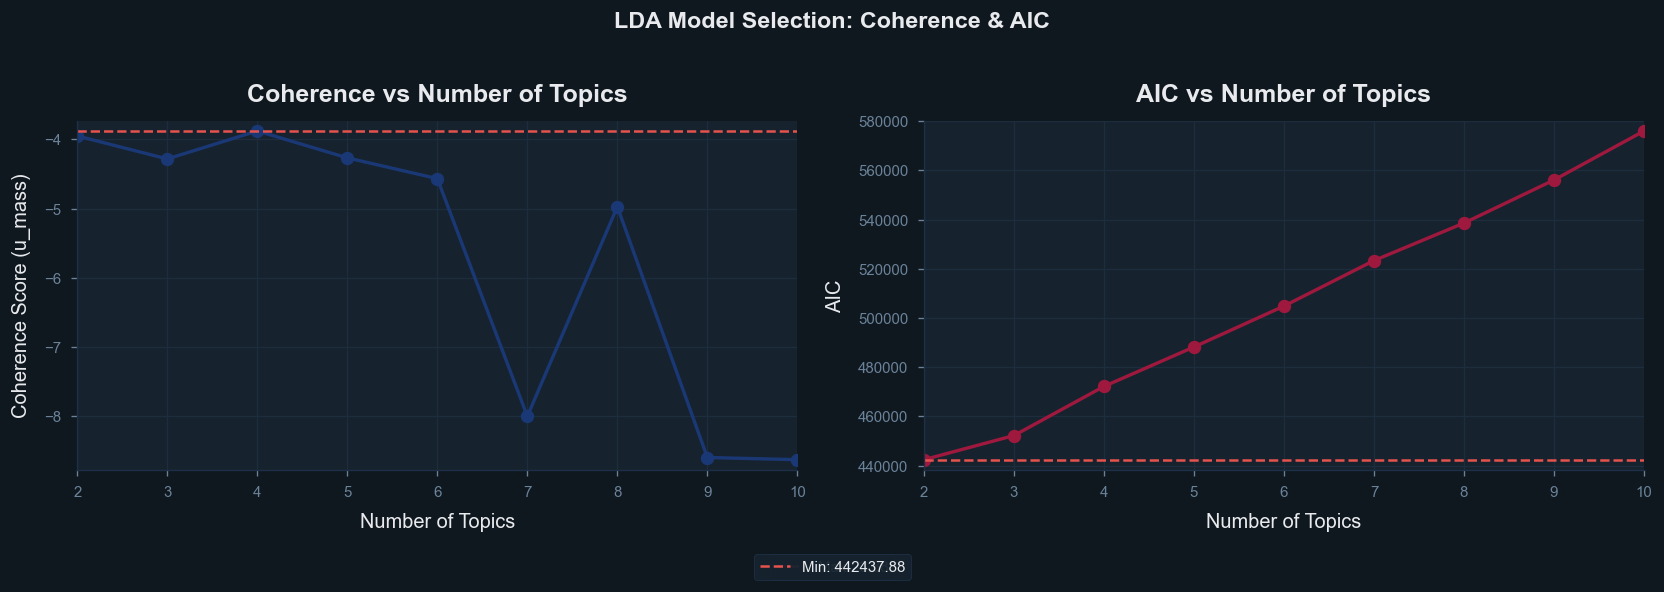


Optimal number of topics (coherence): 4
  Coherence: -3.8780
  AIC at optimal: 472220.92


In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle("LDA Model Selection: Coherence & AIC", color=TEXT_PRIMARY,
             fontsize=14, fontweight="bold")

for ax, scores, ylabel, title, color in [
    (ax1, coherence_scores_lda, "Coherence Score (u_mass)", "Coherence vs Number of Topics", TM_DEEP_BLUE),
    (ax2, aic_scores_lda,       "AIC",                      "AIC vs Number of Topics",       TM_CRIMSON),
]:
    style_ax(ax, xlabel="Number of Topics", ylabel=ylabel, title=title)
    ax.plot(list(topic_range), scores, marker="o", color=color, linewidth=2, markersize=7)
    best_val = max(scores) if "Coherence" in ylabel else min(scores)
    ax.axhline(best_val, color=REPUBLICAN, lw=1.5, ls="--",
               label=f'{"Max" if "Coherence" in ylabel else "Min"}: {best_val:.2f}')
    place_legends_bottom(ax, main_ncol=1, main_y=0.02, event_y=-0.15)

plt.tight_layout(rect=[0, 0.08, 1, 0.96])
fig.savefig(FIGURES_DIR / "nlp_1_coherence.png", dpi=150, bbox_inches="tight",
            facecolor=BG_DARK, edgecolor="none")
plt.show()

optimal_topics_lda = list(topic_range)[np.argmax(coherence_scores_lda)]
print(f"\nOptimal number of topics (coherence): {optimal_topics_lda}")
print(f"  Coherence: {max(coherence_scores_lda):.4f}")
print(f"  AIC at optimal: {aic_scores_lda[list(topic_range).index(optimal_topics_lda)]:.2f}")

In [26]:
# Coherence sweep results table
sweep_df = pd.DataFrame({
    "# Topics": list(topic_range),
    "Coherence (u_mass)": [f"{s:.4f}" for s in coherence_scores_lda],
    "AIC": [f"{s:,.0f}" for s in aic_scores_lda],
    "Selected": ["*" if i == optimal_topics_lda - list(topic_range)[0] else "" for i in range(len(list(topic_range)))],
})
render_table_png(
    sweep_df,
    TABLES_DIR / "nlp_coherence_sweep.png",
    title="LDA Coherence & AIC Sweep Results",
)
print("Saved nlp_coherence_sweep.png")
display(sweep_df)

Saved nlp_coherence_sweep.png


,# Topics,Coherence (u_mass),AIC,Selected
0,2,-3.9504,"442,438",
1,3,-4.2822,"452,248",
2,4,-3.8780,"472,221",*
3,5,-4.2668,"488,255",
4,6,-4.5669,"504,882",
5,7,-8.0028,"523,380",
6,8,-4.9725,"538,635",
7,9,-8.5988,"556,141",
8,10,-8.6301,"576,068",


## 4. LDA Ã¢â‚¬â€ Train Final Model

In [27]:
print(f"Training final LDA model with {optimal_topics_lda} topics...")

lda_train_start = time.time()
lda_model = LdaModel(
    corpus=corpus, id2word=dictionary,
    num_topics=optimal_topics_lda, random_state=42,
    passes=15, iterations=400,
    alpha="auto", eta="auto", per_word_topics=True
)
lda_train_time = time.time() - lda_train_start
print(f"LDA trained in {lda_train_time:.1f}s")

cm_final = CoherenceModel(model=lda_model, texts=tokenized_docs,
                          dictionary=dictionary, coherence="u_mass")
coherence_lda_final = cm_final.get_coherence()
print(f"Final LDA Coherence (u_mass): {coherence_lda_final:.4f}")

# Model summary table
model_summary = pd.DataFrame({
    "Parameter": [
        "Number of topics",
        "Passes",
        "Iterations",
        "Alpha",
        "Eta",
        "Dictionary size",
        "Corpus size",
        "Training time (s)",
        "Final coherence (u_mass)",
    ],
    "Value": [
        str(optimal_topics_lda),
        "15",
        "400",
        "auto",
        "auto",
        f"{len(dictionary):,}",
        f"{len(corpus):,}",
        f"{lda_train_time:.1f}",
        f"{coherence_lda_final:.4f}",
    ],
})
render_table_png(
    model_summary,
    TABLES_DIR / "nlp_model_summary.png",
    title="Final LDA Model Configuration",
)
print("Saved nlp_model_summary.png")
display(model_summary)

Training final LDA model with 4 topics...
LDA trained in 97.1s
Final LDA Coherence (u_mass): -3.1027
Saved nlp_model_summary.png


,Parameter,Value
0,Number of topics,4
1,Passes,15
2,Iterations,400
3,Alpha,auto
4,Eta,auto
5,Dictionary size,"8,008"
6,Corpus size,"26,858"
7,Training time (s),97.1
8,Final coherence (u_mass),-3.1027


In [28]:
lda_topics = []
rows = []
for i in range(lda_model.num_topics):
    word_weights = lda_model.show_topic(i, topn=10)
    words = [w for w, _ in word_weights]
    lda_topics.append(words)
    rows.append({
        "Topic": f"Topic {i}",
        "Top 10 words": ", ".join(words),
        "Top weight": f"{word_weights[0][1]:.3f}",
    })
    print(f"LDA Topic {i}: {chr(44).join(words)}")

topic_words_df = pd.DataFrame(rows)
render_table_png(
    topic_words_df,
    TABLES_DIR / "nlp_topic_words.png",
    title="LDA Topic Keywords (Top 10 Words per Topic)",
)
print("Saved nlp_topic_words.png")
display(topic_words_df)

LDA Topic 0: trump,election,maga,republicans,democrats,gop,politics,social,voteblue,harris
LDA Topic 1: trump,debate,like,people,one,vance,would,get,good,harris
LDA Topic 2: dnc,vpdebate,vote,walz,harriswalz,kamalaharris,kamala,democrats,timwalz,harris
LDA Topic 3: house,latest,action,rep,sponsor,status,sponsors,introduced,committee,congress
Saved nlp_topic_words.png


,Topic,Top 10 words,Top weight
0,Topic 0,"trump, election, maga, republicans, democrats,...",0.034
1,Topic 1,"trump, debate, like, people, one, vance, would...",0.023
2,Topic 2,"dnc, vpdebate, vote, walz, harriswalz, kamalah...",0.038
3,Topic 3,"house, latest, action, rep, sponsor, status, s...",0.041


Saved nlp_2_wordclouds.png


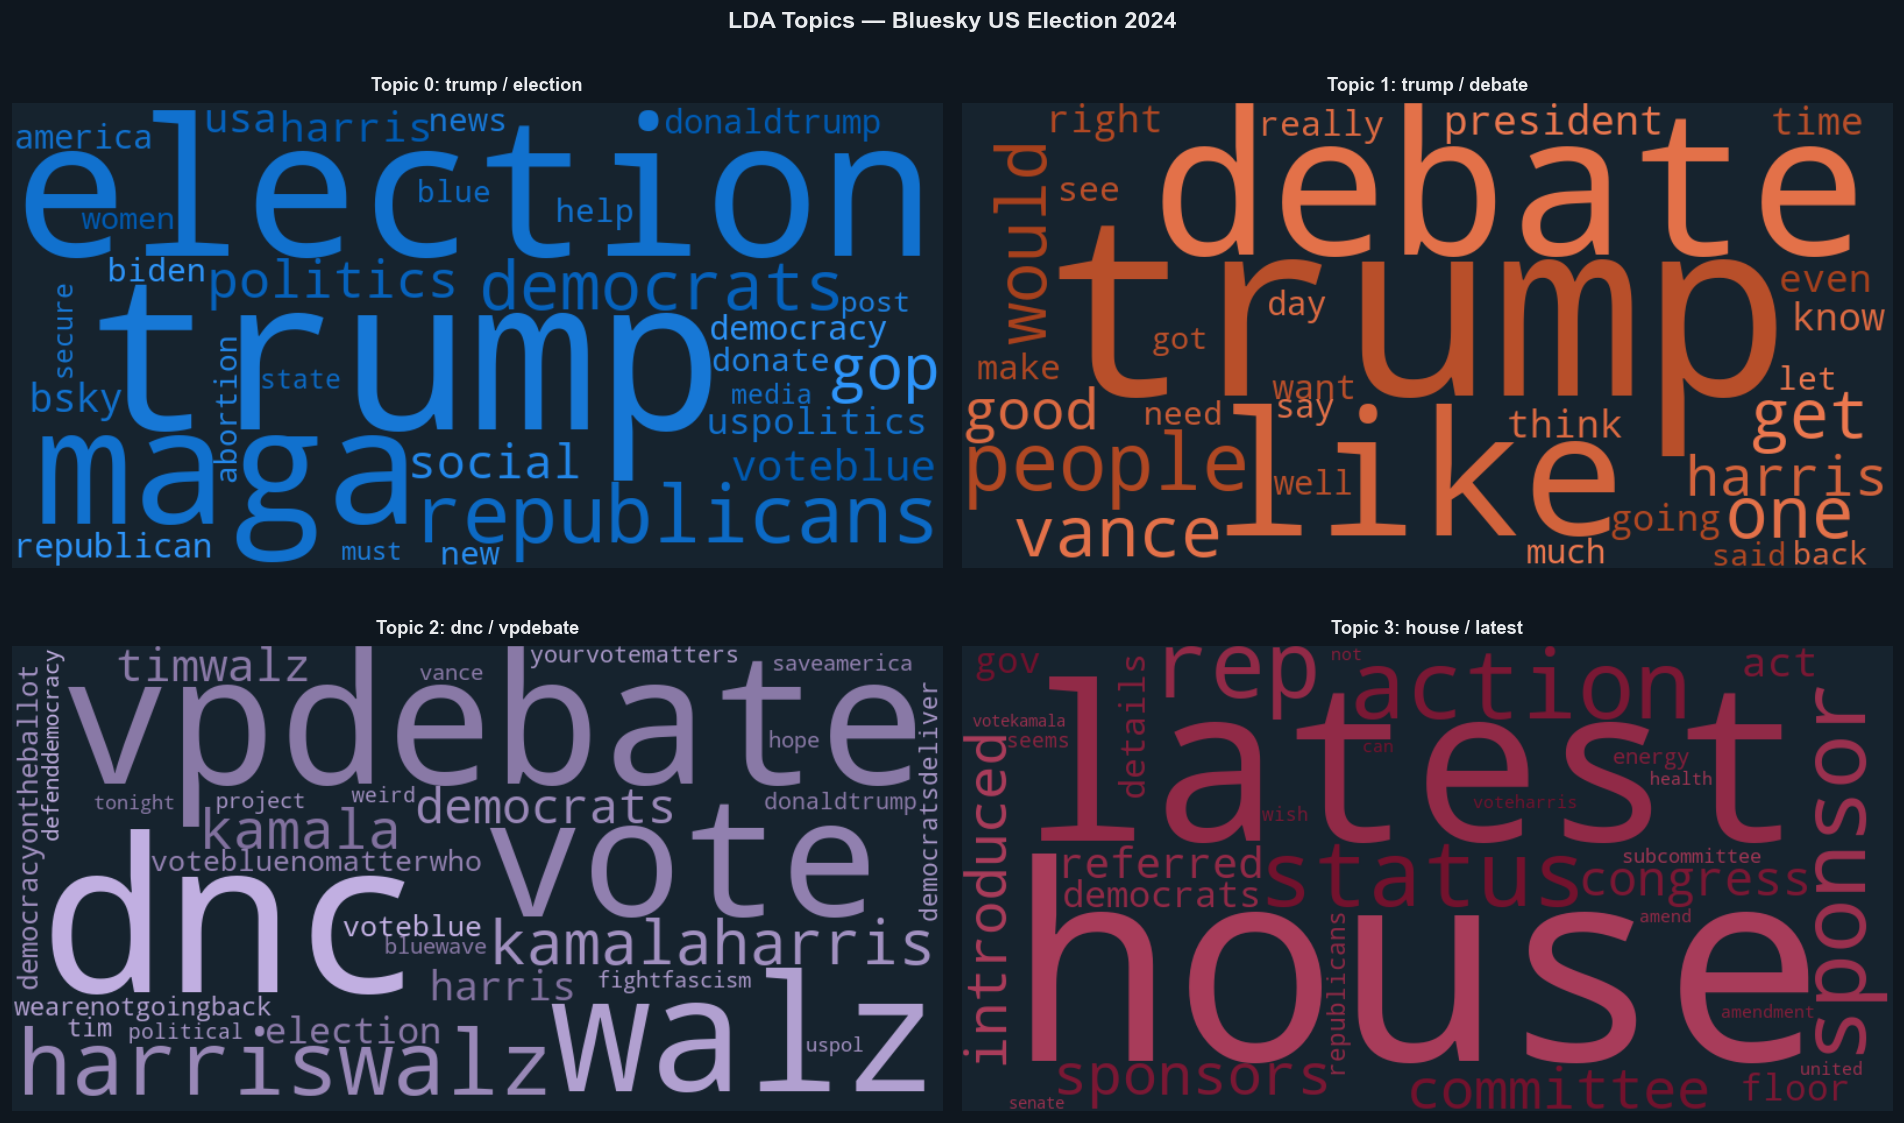

In [29]:
n_topics_lda = lda_model.num_topics
n_cols = 2
n_rows = (n_topics_lda + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
fig.patch.set_facecolor(BG_DARK)
axes = axes.flatten()

for topic_id in range(n_topics_lda):
    topic_data   = lda_model.show_topic(topic_id, topn=30)
    word_weights = {word: weight for word, weight in topic_data}

    wc = WordCloud(
        width=800, height=400,
        background_color=BG_PANEL,
        color_func=wordcloud_color_func(topic_id=topic_id, seed=42, n_shades=9),
        max_words=30,
        prefer_horizontal=0.9
    ).generate_from_frequencies(word_weights)

    ax = axes[topic_id]
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_facecolor(BG_DARK)
    ax.set_title(f"Topic {topic_id}: {lda_topics[topic_id][0]} / {lda_topics[topic_id][1]}",
                 color=TEXT_PRIMARY, fontweight="bold", fontsize=11, pad=8)

for i in range(n_topics_lda, len(axes)):
    axes[i].set_visible(False)

fig.suptitle("LDA Topics — Bluesky US Election 2024",
             color=TEXT_PRIMARY, fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "nlp_2_wordclouds.png", dpi=150, bbox_inches="tight",
            facecolor=BG_DARK, edgecolor="none")
print("Saved nlp_2_wordclouds.png")
plt.show()

Saved nlp_3_topics_time.png


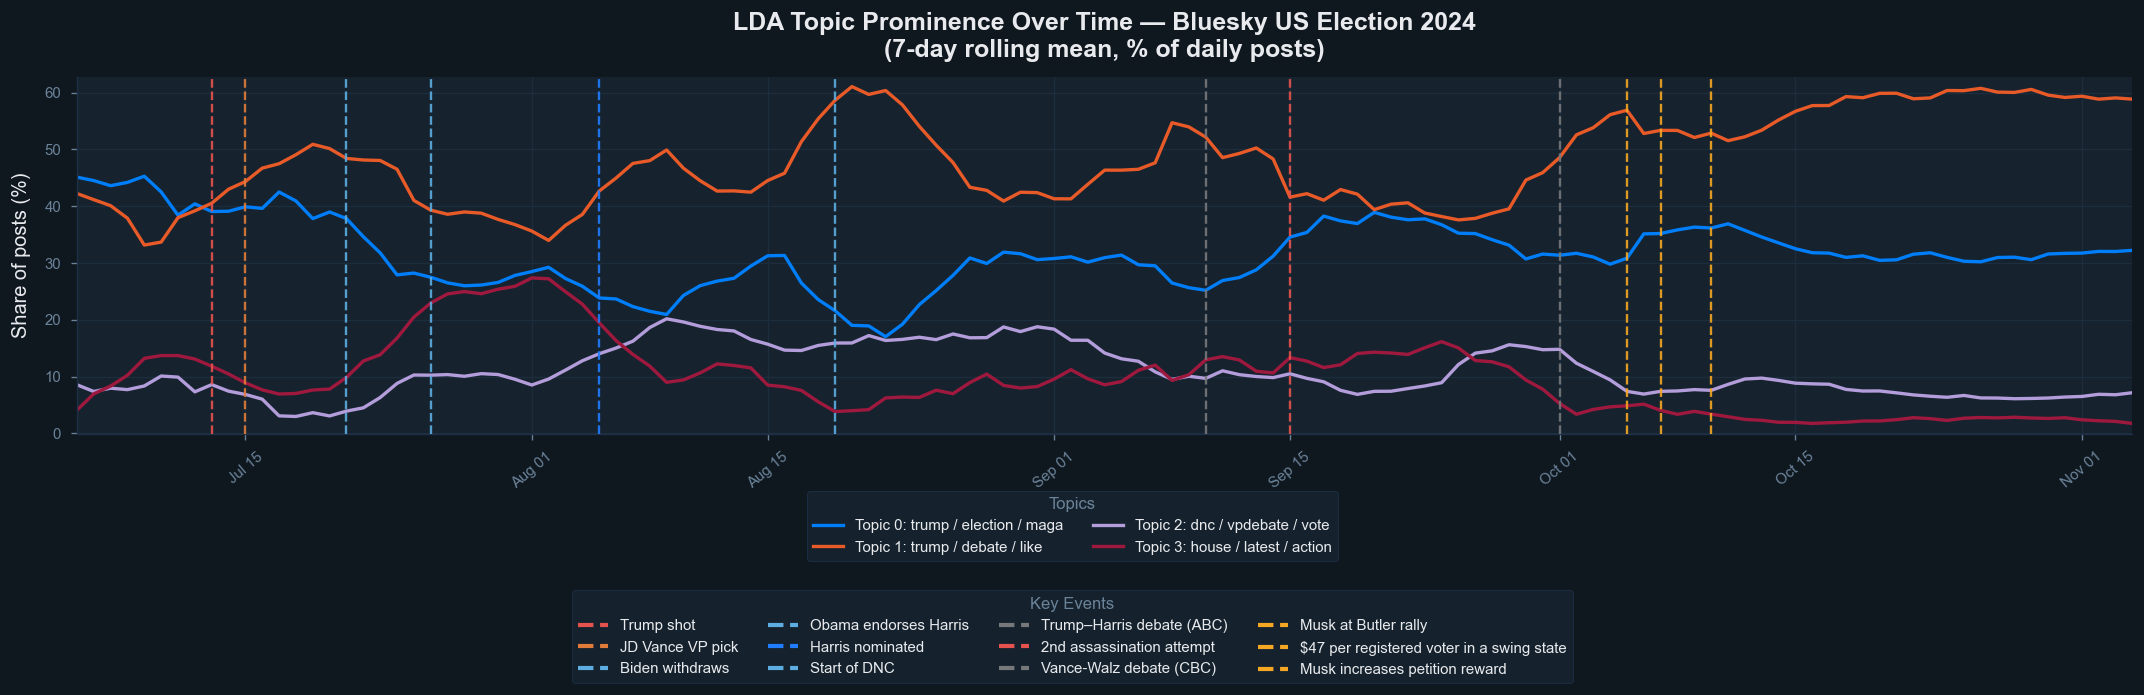

In [34]:
# Assign dominant LDA topic to each post
def get_dominant_topic_lda(ldamodel, corpus):
    dominant = []
    for doc in corpus:
        dist = ldamodel.get_document_topics(doc)
        dominant.append(sorted(dist, key=lambda x: x[1], reverse=True)[0][0] if dist else -1)
    return dominant

df_lda["lda_topic"] = get_dominant_topic_lda(lda_model, corpus)

topic_labels = {
    i: " / ".join([w for w, _ in lda_model.show_topic(i, topn=3)])
    for i in range(lda_model.num_topics)
}

daily_topic_counts = (
    df_lda.groupby(["timestamp", "lda_topic"])
    .size()
    .reset_index(name="post_count")
)
daily_totals = df_lda.groupby("timestamp").size().reset_index(name="total")
daily_topic_counts = daily_topic_counts.merge(daily_totals, on="timestamp")
daily_topic_counts["share"] = daily_topic_counts["post_count"] / daily_topic_counts["total"] * 100

topic_share_pivot = (
    daily_topic_counts
    .pivot(index="timestamp", columns="lda_topic", values="share")
    .fillna(0)
)
topic_share_pivot.index = pd.to_datetime(topic_share_pivot.index)
topic_share_pivot = topic_share_pivot.sort_index()
# Limit to Nov 4, 2024 (end of election day)
topic_share_pivot = topic_share_pivot[topic_share_pivot.index <= pd.Timestamp('2024-11-04', tz='UTC')]

fig, ax = plt.subplots(figsize=(18, 6))
fig.patch.set_facecolor(BG_DARK)
style_ax(ax, ylabel="Share of posts (%)",
         title="LDA Topic Prominence Over Time — Bluesky US Election 2024\n(7-day rolling mean, % of daily posts)")

for topic_id in topic_share_pivot.columns:
    smooth = topic_share_pivot[topic_id].rolling(7, center=True, min_periods=3).mean()
    ax.plot(
        topic_share_pivot.index, smooth,
        label=f"Topic {topic_id}: {topic_labels[topic_id]}",
        linewidth=2, color=TOPIC_MODEL_COLORS[int(topic_id) % len(TOPIC_MODEL_COLORS)]
    )

add_events(ax)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.tick_params(axis="x", rotation=40)

event_handles = event_legend_handles(EVENTS)
place_legends_bottom(
    ax,
    event_handles=event_handles,
    main_ncol=2, event_ncol=4,
    main_y=0.20, event_y=0.03,
    main_title="Topics", event_title="Key Events",
)
plt.tight_layout(rect=[0, 0.28, 1, 1])
fig.savefig(FIGURES_DIR / "nlp_3_topics_time.png", dpi=150, bbox_inches="tight",
            facecolor=BG_DARK, edgecolor="none")
print("Saved nlp_3_topics_time.png")
plt.show()

## 5. Topic per Buzz Group

Saved nlp_4_topics_buzzgroup.png


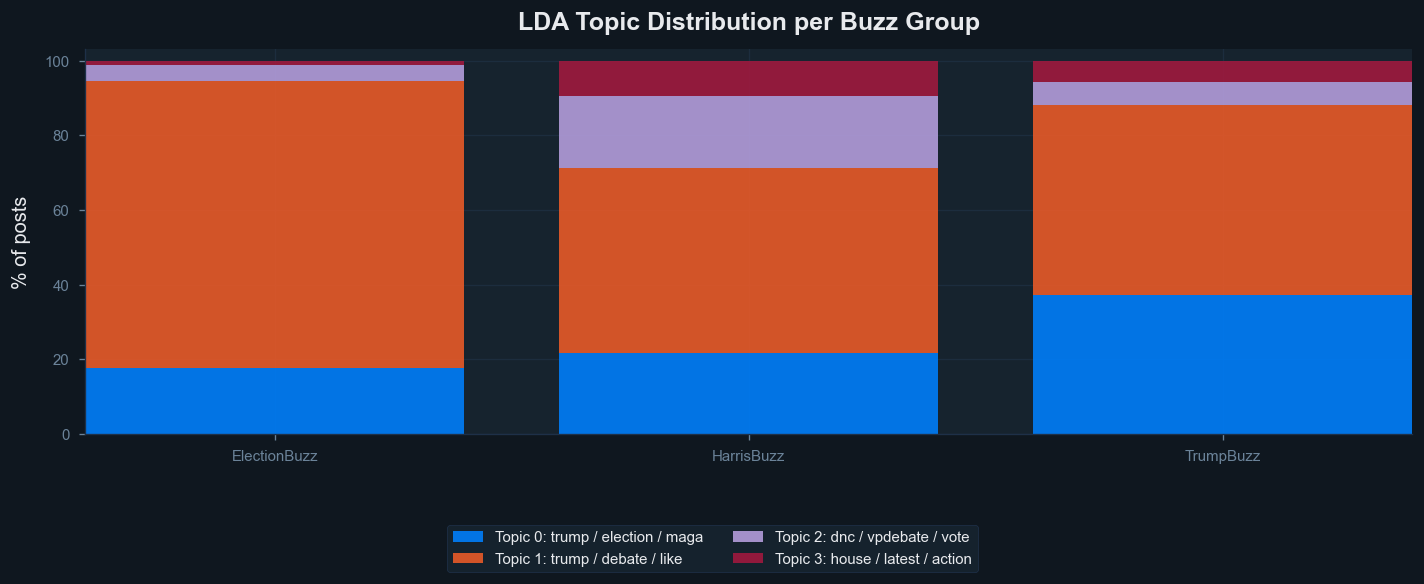

In [31]:
lda_buzz     = df_lda.groupby(["candidate", "lda_topic"]).size().unstack(fill_value=0)
lda_buzz_pct = lda_buzz.div(lda_buzz.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG_DARK)
style_ax(ax, ylabel="% of posts",
         title="LDA Topic Distribution per Buzz Group")

bottom = np.zeros(len(lda_buzz_pct))
for i, col in enumerate(lda_buzz_pct.columns):
    ax.bar(
        lda_buzz_pct.index,
        lda_buzz_pct[col],
        bottom=bottom,
        label=f"Topic {col}: {topic_labels[col]}",
        color=TOPIC_MODEL_COLORS[i % len(TOPIC_MODEL_COLORS)],
        edgecolor="none",
        alpha=0.9,
    )
    bottom += lda_buzz_pct[col].values

place_legends_bottom(ax, main_ncol=2, main_y=0.02, event_y=-0.15)
plt.tight_layout(rect=[0, 0.18, 1, 1])
fig.savefig(FIGURES_DIR / "nlp_4_topics_buzzgroup.png", dpi=150, bbox_inches="tight",
            facecolor=BG_DARK, edgecolor="none")
print("Saved nlp_4_topics_buzzgroup.png")
plt.show()

In [32]:
# Topic distribution per buzz group — table
buzz_table = lda_buzz_pct.copy().round(1)
buzz_table.columns = [f"Topic {c} (%)" for c in buzz_table.columns]
buzz_table.index.name = "Buzz Group"
buzz_table = buzz_table.reset_index()
render_table_png(
    buzz_table,
    TABLES_DIR / "nlp_topic_buzzgroup.png",
    title="LDA Topic Distribution per Buzz Group (%)",
)
print("Saved nlp_topic_buzzgroup.png")
display(buzz_table)

Saved nlp_topic_buzzgroup.png


,Buzz Group,Topic 0 (%),Topic 1 (%),Topic 2 (%),Topic 3 (%)
0,ElectionBuzz,17.6,76.9,4.4,1.1
1,HarrisBuzz,21.7,49.5,19.3,9.5
2,TrumpBuzz,37.2,50.9,6.2,5.6
